# Problem 1: 2D Heat Diffusion with Convergence Detection (CUDA, T4 GPU)

This notebook implements the standard **5-point discrete Jacobi stencil** heat diffusion simulation in CUDA C++.
It compares a **global memory** implementation with a **shared memory tiled** implementation,
detects convergence on the GPU using a parallel reduction with atomicMax, and avoids
transferring the full temperature grid between CPU and GPU on every iteration. Only a
single scalar convergence value is transferred per iteration; the full grid is transferred
once at the end of each run.

---

### 1. Mathematical Coordinate System (Cartesian Grid $(x_i, y_j) = (i, j)$)
Following standard PDE finite-difference discretization and Steven C. Chapra, *Numerical Methods for Engineers* (Figure 29.4):
* **Horizontal axis ($x$):** Indexed by **$i$** spanning from Left to Right ($0 \le i \le N-1$).
* **Vertical axis ($y$):** Indexed by **$j$** spanning from Bottom to Top ($0 \le j \le N-1$).

For any central interior cell $(i, j)$:
* **Right Neighbor:** $(i + 1, j)$ &nbsp;&mdash;&nbsp; step rightward along $+x$
* **Left Neighbor:** $(i - 1, j)$ &nbsp;&mdash;&nbsp; step leftward along $-x$
* **Top Neighbor:** $(i, j + 1)$ &nbsp;&mdash;&nbsp; step upward along $+y$
* **Bottom Neighbor:** $(i, j - 1)$ &nbsp;&mdash;&nbsp; step downward along $-y$

The standard 5-point discrete Laplace stencil computes the neighbor average:
$$T(i, j)^{(t+1)} = \frac{T(i+1, j)^t + T(i-1, j)^t + T(i, j+1)^t + T(i, j-1)^t}{4} = \frac{T_{\text{right}} + T_{\text{left}} + T_{\text{top}} + T_{\text{bottom}}}{4}$$

---

### 2. Dirichlet Boundary Conditions
* **Top Boundary ($y = H$):** $j = N-1, \quad i \in [0, N-1] \implies T(i, N-1) = T_{\text{top}}$ (Fixed $100^\circ\text{C}$)
* **Bottom Boundary ($y = 0$):** $j = 0, \quad i \in [0, N-1] \implies T(i, 0) = T_{\text{bottom}}$ (Fixed $0^\circ\text{C}$)
* **Left Boundary ($x = 0$):** $i = 0, \quad j \in [0, N-1] \implies T(0, j) = T_{\text{left}}$ (Fixed $75^\circ\text{C}$)
* **Right Boundary ($x = W$):** $i = N-1, \quad j \in [0, N-1] \implies T(N-1, j) = T_{\text{right}}$ (Fixed $50^\circ\text{C}$)

---

### 3. Coordinate Mapping to C / CUDA 1D Row-Major Memory
In GPU memory, a 2D matrix is flattened row-by-row into a 1D linear array:
$$\text{Address: } \text{idx} = \text{row} \times N + \text{col}$$

* **Column index `col`:** Horizontal position ($0 = \text{Left}$, $N-1 = \text{Right}$)
* **Row index `row`:** Vertical position ($0 = \text{Top}$, $N-1 = \text{Bottom}$)
* **Top Neighbor (`up`):** `T[idx - N]` &nbsp;&mdash;&nbsp; row above (`row - 1`)
* **Bottom Neighbor (`down`):** `T[idx + N]` &nbsp;&mdash;&nbsp; row below (`row + 1`)
* **Left Neighbor (`left`):** `T[idx - 1]` &nbsp;&mdash;&nbsp; column to left (`col - 1`)
* **Right Neighbor (`right`):** `T[idx + 1]` &nbsp;&mdash;&nbsp; column to right (`col + 1`)

Run the cells in order on a Colab runtime with a T4 GPU (Runtime > Change runtime type > T4 GPU).


In [1]:
!nvidia-smi

Mon Sep 14 05:51:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## CUDA source code (No SOR - Pure 5-Point Jacobi Stencil)
Implements standard Jacobi updates with explicit coordinates:
* `up` (Top): `idx - N` (Row `row - 1`)
* `down` (Bottom): `idx + N` (Row `row + 1`)
* `left` (Left): `idx - 1` (Col `col - 1`)
* `right` (Right): `idx + 1` (Col `col + 1`)


In [2]:
%%writefile heat_diffusion.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <vector>
#include <string>
#include <cuda_runtime.h>

#define BLOCK 16
#define GLOBAL_MODE 0
#define SHARED_MODE 1

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            fprintf(stderr, "CUDA error %s at line %d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
            exit(1); \
        } \
    } while (0)

__device__ float g_maxdiff;

__global__ void heatKernelGlobal(const float* T, float* Tnew, int N)
{
    extern __shared__ float sdata[];
    int col = blockIdx.x * blockDim.x + threadIdx.x + 1;
    int row = blockIdx.y * blockDim.y + threadIdx.y + 1;
    int tid = threadIdx.y * blockDim.x + threadIdx.x;

    float diff = 0.0f;
    if (row <= N - 2 && col <= N - 2) {
        int idx = row * N + col;
        // Coordinate Lookups in row-major memory:
        float up    = T[idx - N]; // Top neighbor:    (row - 1, col) -> (i, j + 1) in math
        float down  = T[idx + N]; // Bottom neighbor: (row + 1, col) -> (i, j - 1) in math
        float left  = T[idx - 1]; // Left neighbor:   (row, col - 1) -> (i - 1, j) in math
        float right = T[idx + 1]; // Right neighbor:  (row, col + 1) -> (i + 1, j) in math
        float newval = 0.25f * (up + down + left + right);
        diff = fabsf(newval - T[idx]);
        Tnew[idx] = newval;
    }

    sdata[tid] = diff;
    __syncthreads();

    for (int s = (blockDim.x * blockDim.y) / 2; s > 0; s >>= 1) {
        if (tid < s) sdata[tid] = fmaxf(sdata[tid], sdata[tid + s]);
        __syncthreads();
    }

    if (tid == 0) atomicMax((int*)&g_maxdiff, __float_as_int(sdata[0]));
}

__global__ void heatKernelShared(const float* T, float* Tnew, int N)
{
    extern __shared__ float smemAll[];
    int tileDim = blockDim.x + 2;
    float* tile = smemAll;
    float* sdata = smemAll + tileDim * tileDim;

    int col = blockIdx.x * blockDim.x + threadIdx.x + 1;
    int row = blockIdx.y * blockDim.y + threadIdx.y + 1;
    int lx = threadIdx.x + 1;
    int ly = threadIdx.y + 1;

    int colc = min(col, N - 1);
    int rowc = min(row, N - 1);

    tile[ly * tileDim + lx] = T[rowc * N + colc];

    if (threadIdx.x == 0) {
        int leftCol = max(col - 1, 0);
        tile[ly * tileDim + 0] = T[rowc * N + leftCol];
    }
    if (threadIdx.x == blockDim.x - 1) {
        int rightCol = min(col + 1, N - 1);
        tile[ly * tileDim + (lx + 1)] = T[rowc * N + rightCol];
    }
    if (threadIdx.y == 0) {
        int upRow = max(row - 1, 0);
        tile[0 * tileDim + lx] = T[upRow * N + colc];
    }
    if (threadIdx.y == blockDim.y - 1) {
        int downRow = min(row + 1, N - 1);
        tile[(ly + 1) * tileDim + lx] = T[downRow * N + colc];
    }

    __syncthreads();

    int tid = threadIdx.y * blockDim.x + threadIdx.x;
    float diff = 0.0f;
    bool valid = (row <= N - 2 && col <= N - 2);

    if (valid) {
        // Coordinate Lookups in fast on-chip shared memory:
        float up    = tile[(ly - 1) * tileDim + lx]; // Top neighbor in tile
        float down  = tile[(ly + 1) * tileDim + lx]; // Bottom neighbor in tile
        float left  = tile[ly * tileDim + (lx - 1)]; // Left neighbor in tile
        float right = tile[ly * tileDim + (lx + 1)]; // Right neighbor in tile
        float newval = 0.25f * (up + down + left + right);
        int idx = row * N + col;
        diff = fabsf(newval - T[idx]);
        Tnew[idx] = newval;
    }

    sdata[tid] = diff;
    __syncthreads();

    for (int s = (blockDim.x * blockDim.y) / 2; s > 0; s >>= 1) {
        if (tid < s) sdata[tid] = fmaxf(sdata[tid], sdata[tid + s]);
        __syncthreads();
    }

    if (tid == 0) atomicMax((int*)&g_maxdiff, __float_as_int(sdata[0]));
}

struct SimResult {
    long long iterations;
    float time_ms;
    bool converged;
    float final_max_diff;
    std::vector<float> grid;
};

void initGrid(std::vector<float>& g, int N, float topT, float bottomT, float leftT, float rightT, float initTemp)
{
    g.assign((size_t)N * N, initTemp);
    for (int j = 0; j < N; j++) {
        g[0 * N + j] = topT;
        g[(N - 1) * N + j] = bottomT;
    }
    for (int i = 0; i < N; i++) {
        g[i * N + 0] = leftT;
        g[i * N + (N - 1)] = rightT;
    }
}

SimResult runSimulation(int N, float tol, long long maxIter, int mode,
                         float topT, float bottomT, float leftT, float rightT, float initTemp,
                         bool dump, const char* fname)
{
    SimResult result;
    std::vector<float> h_init;
    initGrid(h_init, N, topT, bottomT, leftT, rightT, initTemp);

    float *d_A, *d_B;
    size_t bytes = (size_t)N * N * sizeof(float);
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMemcpy(d_A, h_init.data(), bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, h_init.data(), bytes, cudaMemcpyHostToDevice));

    dim3 block(BLOCK, BLOCK);
    int interior = N - 2;
    dim3 grid((interior + BLOCK - 1) / BLOCK, (interior + BLOCK - 1) / BLOCK);

    size_t sharedBytesGlobal = block.x * block.y * sizeof(float);
    size_t tileDim = block.x + 2;
    size_t sharedBytesShared = tileDim * tileDim * sizeof(float) + block.x * block.y * sizeof(float);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    float* dA = d_A;
    float* dB = d_B;
    long long iter = 0;
    float diffVal = 1e30f;
    float zero = 0.0f;

    CUDA_CHECK(cudaEventRecord(start));

    while (diffVal > tol && iter < maxIter) {
        CUDA_CHECK(cudaMemcpyToSymbol(g_maxdiff, &zero, sizeof(float)));

        if (mode == GLOBAL_MODE) {
            heatKernelGlobal<<<grid, block, sharedBytesGlobal>>>(dA, dB, N);
        } else {
            heatKernelShared<<<grid, block, sharedBytesShared>>>(dA, dB, N);
        }
        CUDA_CHECK(cudaGetLastError());

        CUDA_CHECK(cudaMemcpyFromSymbol(&diffVal, g_maxdiff, sizeof(float)));

        float* tmp = dA;
        dA = dB;
        dB = tmp;

        iter++;
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float ms = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));

    result.iterations = iter;
    result.time_ms = ms;
    result.converged = (diffVal <= tol);
    result.final_max_diff = diffVal;
    result.grid.assign((size_t)N * N, 0.0f);
    CUDA_CHECK(cudaMemcpy(result.grid.data(), dA, bytes, cudaMemcpyDeviceToHost));

    if (dump && fname != nullptr) {
        FILE* f = fopen(fname, "w");
        for (int i = 0; i < N; i++) {
            for (int j = 0; j < N; j++) {
                fprintf(f, "%f", result.grid[i * N + j]);
                if (j < N - 1) fprintf(f, ",");
            }
            fprintf(f, "\n");
        }
        fclose(f);
    }

    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));
    CUDA_CHECK(cudaFree(d_A));
    CUDA_CHECK(cudaFree(d_B));

    return result;
}

int main(int argc, char** argv)
{
    int N = 256;
    float eps = 1e-4f;
    long long maxIter = 2000000;
    float topT = 100.0f;
    float bottomT = 0.0f;
    float leftT = 75.0f;
    float rightT = 50.0f;
    float initTemp = 0.0f;

    if (argc > 1) N = atoi(argv[1]);
    if (argc > 2) eps = (float)atof(argv[2]);
    if (argc > 3) maxIter = atoll(argv[3]);
    if (argc > 4) topT = (float)atof(argv[4]);
    if (argc > 5) bottomT = (float)atof(argv[5]);
    if (argc > 6) leftT = (float)atof(argv[6]);
    if (argc > 7) rightT = (float)atof(argv[7]);
    if (argc > 8) initTemp = (float)atof(argv[8]);

    if (N < 3) {
        fprintf(stderr, "N must be at least 3\n");
        return 1;
    }

    char fnameGlobal[256];
    char fnameShared[256];
    snprintf(fnameGlobal, sizeof(fnameGlobal), "grid_global_%d.csv", N);
    snprintf(fnameShared, sizeof(fnameShared), "grid_shared_%d.csv", N);

    SimResult rG = runSimulation(N, eps, maxIter, GLOBAL_MODE, topT, bottomT, leftT, rightT, initTemp, true, fnameGlobal);
    SimResult rS = runSimulation(N, eps, maxIter, SHARED_MODE, topT, bottomT, leftT, rightT, initTemp, true, fnameShared);

    printf("RESULT_CSV\n");
    printf("N,mode,iterations,time_ms,converged,final_max_diff\n");
    printf("%d,global,%lld,%f,%d,%e\n", N, rG.iterations, rG.time_ms, rG.converged ? 1 : 0, rG.final_max_diff);
    printf("%d,shared,%lld,%f,%d,%e\n", N, rS.iterations, rS.time_ms, rS.converged ? 1 : 0, rS.final_max_diff);

    float maxDiff = 0.0f;
    for (size_t i = 0; i < rG.grid.size(); i++) {
        float d = fabsf(rG.grid[i] - rS.grid[i]);
        if (d > maxDiff) maxDiff = d;
    }

    printf("CORRECTNESS_CSV\n");
    printf("N,max_diff_global_vs_shared\n");
    printf("%d,%e\n", N, maxDiff);

    return 0;
}


Writing heat_diffusion.cu


## Compile for T4 (sm_75)

In [3]:
!nvcc -O3 -arch=sm_75 heat_diffusion.cu -o heat_diffusion

## Single explicit run (matches the assignment's Input/Output wording directly)

Set the values below and run this cell. These are passed to the compiled program as
real command line arguments, so this is a genuine input to the program, not a hard
coded constant. The program prints back the iterations, execution time, whether it
truly converged, and the final maximum change, for both the global memory and the
shared memory kernel.

In [4]:
import subprocess

N_value = 256
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

cmd = [
    "./heat_diffusion",
    str(N_value),
    str(epsilon_value),
    str(max_iterations),
    str(top_temp),
    str(bottom_temp),
    str(left_temp),
    str(right_temp),
    str(initial_interior_temp)
]

single_run = subprocess.run(cmd, capture_output=True, text=True)
print(" ".join(cmd))
print(single_run.stdout)
if single_run.returncode != 0:
    print(single_run.stderr)

./heat_diffusion 256 0.0001 2000000 100.0 0.0 75.0 50.0 0.0
RESULT_CSV
N,mode,iterations,time_ms,converged,final_max_diff
256,global,57321,1648.257568,1,9.918213e-05
256,shared,57321,1635.580933,1,9.918213e-05
CORRECTNESS_CSV
N,max_diff_global_vs_shared
256,0.000000e+00



## Benchmark across several grid sizes

This calls the same compiled program once per grid size, with the same command line
interface as above, so every run is still a real, explicit input, not a hard coded
sweep inside the C++ file. Larger grids need many more iterations to converge, so this
cell can take a few minutes to finish, mostly spent on N = 1024.

In [5]:
import subprocess

N_list = [128, 256, 512, 1024]
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

result_rows = []
correctness_rows = []

for N in N_list:
    cmd = [
        "./heat_diffusion",
        str(N),
        str(epsilon_value),
        str(max_iterations),
        str(top_temp),
        str(bottom_temp),
        str(left_temp),
        str(right_temp),
        str(initial_interior_temp)
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        print("Run failed for N =", N)
        print(proc.stderr)
        continue

    lines = [line for line in proc.stdout.splitlines() if line.strip() != ""]
    r_idx = lines.index("RESULT_CSV")
    result_rows.append(lines[r_idx + 2])
    result_rows.append(lines[r_idx + 3])

    c_idx = lines.index("CORRECTNESS_CSV")
    correctness_rows.append(lines[c_idx + 2])

    print("Finished N =", N)

result_header = "N,mode,iterations,time_ms,converged,final_max_diff"
correctness_header = "N,max_diff_global_vs_shared"

print("Benchmark complete")

Finished N = 128
Finished N = 256
Finished N = 512
Finished N = 1024
Benchmark complete


## Parse results into a pandas DataFrame

In [6]:
import pandas as pd
from io import StringIO

result_csv_text = "\n".join([result_header] + result_rows)
df = pd.read_csv(StringIO(result_csv_text))
df["converged"] = df["converged"].astype(bool)

correctness_csv_text = "\n".join([correctness_header] + correctness_rows)
correctness_df = pd.read_csv(StringIO(correctness_csv_text))

pivot_time = df.pivot(index="N", columns="mode", values="time_ms").reset_index()
pivot_time.columns = ["N", "time_ms_global", "time_ms_shared"]

pivot_iter = df.pivot(index="N", columns="mode", values="iterations").reset_index()
pivot_iter.columns = ["N", "iterations_global", "iterations_shared"]

pivot_conv = df.pivot(index="N", columns="mode", values="converged").reset_index()
pivot_conv.columns = ["N", "converged_global", "converged_shared"]

pivot_diff = df.pivot(index="N", columns="mode", values="final_max_diff").reset_index()
pivot_diff.columns = ["N", "final_max_diff_global", "final_max_diff_shared"]

summary = pivot_time.merge(pivot_iter, on="N").merge(pivot_conv, on="N").merge(pivot_diff, on="N")
summary["speedup_shared_over_global"] = summary["time_ms_global"] / summary["time_ms_shared"]

print(df)
print(summary)
print(correctness_df)

      N    mode  iterations       time_ms  converged  final_max_diff
0   128  global       18578    373.505554       True        0.000099
1   128  shared       18578    430.628662       True        0.000099
2   256  global       57321   1382.326294       True        0.000099
3   256  shared       57321   1384.508911       True        0.000099
4   512  global      155164   5333.197266       True        0.000099
5   512  shared      155164   5324.261230       True        0.000099
6  1024  global      330990  27399.347656       True        0.000099
7  1024  shared      330990  35031.914062       True        0.000099
      N  time_ms_global  time_ms_shared  iterations_global  iterations_shared  \
0   128      373.505554      430.628662              18578              18578   
1   256     1382.326294     1384.508911              57321              57321   
2   512     5333.197266     5324.261230             155164             155164   
3  1024    27399.347656    35031.914062             330

## Save results to Excel

In [7]:
with pd.ExcelWriter("heat_diffusion_results.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="raw_results", index=False)
    summary.to_excel(writer, sheet_name="summary", index=False)
    correctness_df.to_excel(writer, sheet_name="correctness", index=False)

print("Saved heat_diffusion_results.xlsx")

Saved heat_diffusion_results.xlsx


## Execution time comparison

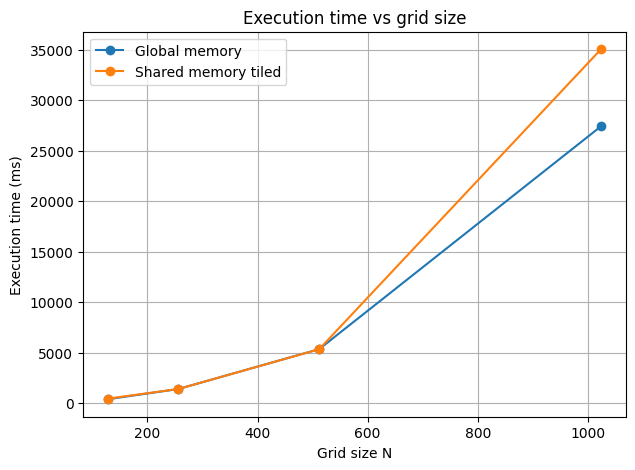

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(summary["N"], summary["time_ms_global"], marker="o", label="Global memory")
plt.plot(summary["N"], summary["time_ms_shared"], marker="o", label="Shared memory tiled")
plt.xlabel("Grid size N")
plt.ylabel("Execution time (ms)")
plt.title("Execution time vs grid size")
plt.legend()
plt.grid(True)
plt.savefig("execution_time.png", dpi=150, bbox_inches="tight")
plt.show()

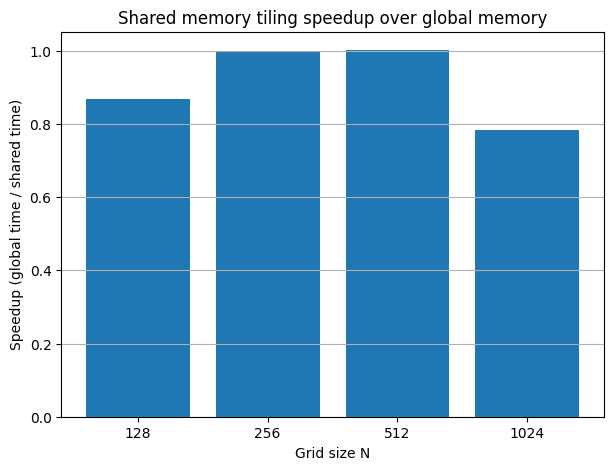

In [9]:
plt.figure(figsize=(7, 5))
plt.bar(summary["N"].astype(str), summary["speedup_shared_over_global"])
plt.xlabel("Grid size N")
plt.ylabel("Speedup (global time / shared time)")
plt.title("Shared memory tiling speedup over global memory")
plt.grid(True, axis="y")
plt.savefig("speedup.png", dpi=150, bbox_inches="tight")
plt.show()

## Iterations to convergence

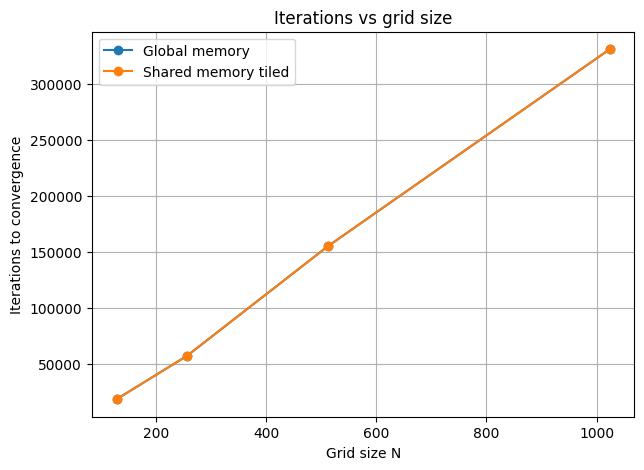

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(summary["N"], summary["iterations_global"], marker="o", label="Global memory")
plt.plot(summary["N"], summary["iterations_shared"], marker="o", label="Shared memory tiled")
plt.xlabel("Grid size N")
plt.ylabel("Iterations to convergence")
plt.title("Iterations vs grid size")
plt.legend()
plt.grid(True)
plt.savefig("iterations.png", dpi=150, bbox_inches="tight")
plt.show()

## Converged temperature field visualization

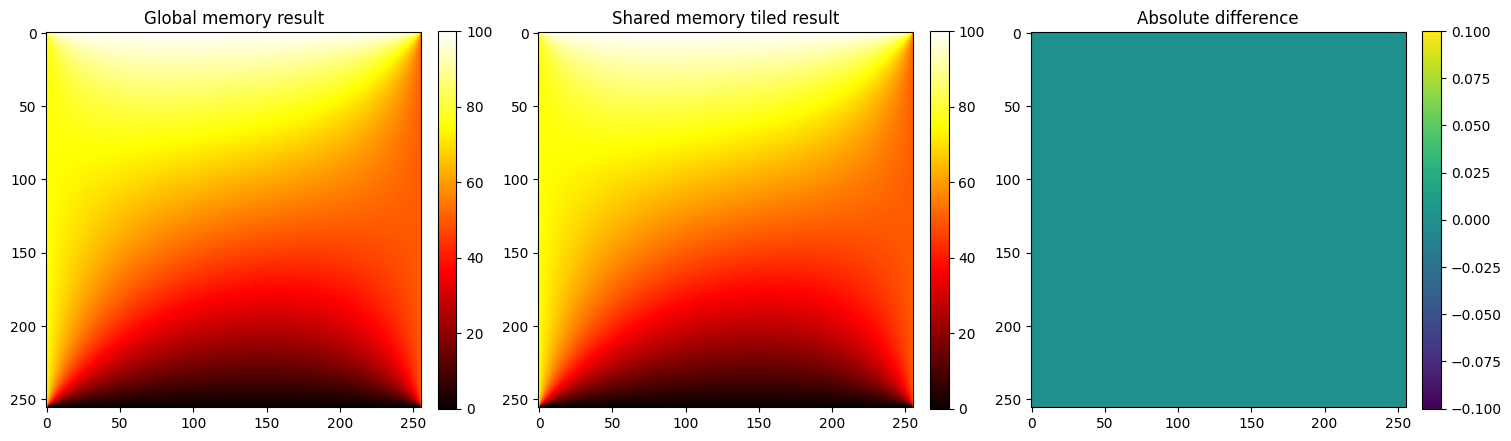

In [11]:
import numpy as np

viz_N = 256

grid_global = np.loadtxt(f"grid_global_{viz_N}.csv", delimiter=",")
grid_shared = np.loadtxt(f"grid_shared_{viz_N}.csv", delimiter=",")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(grid_global, cmap="hot")
axes[0].set_title("Global memory result")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(grid_shared, cmap="hot")
axes[1].set_title("Shared memory tiled result")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

diff = np.abs(grid_global - grid_shared)
im2 = axes[2].imshow(diff, cmap="viridis")
axes[2].set_title("Absolute difference")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.savefig("temperature_field.png", dpi=150, bbox_inches="tight")
plt.show()

## Final summary

In [12]:
print(summary.to_string(index=False))
print(correctness_df.to_string(index=False))

if summary[["converged_global", "converged_shared"]].all(axis=None):
    print("All runs converged within the iteration limit.")
else:
    print("Some runs did not converge within the iteration limit. Increase max_iterations and rerun.")

   N  time_ms_global  time_ms_shared  iterations_global  iterations_shared  converged_global  converged_shared  final_max_diff_global  final_max_diff_shared  speedup_shared_over_global
 128      373.505554      430.628662              18578              18578              True              True               0.000099               0.000099                    0.867349
 256     1382.326294     1384.508911              57321              57321              True              True               0.000099               0.000099                    0.998424
 512     5333.197266     5324.261230             155164             155164              True              True               0.000099               0.000099                    1.001678
1024    27399.347656    35031.914062             330990             330990              True              True               0.000099               0.000099                    0.782125
   N  max_diff_global_vs_shared
 128                        0.0
 256       